In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("/Users/jamesemcnally/Dropbox/DSBC Student Risk Factors Datasets/merged_streaming_data.csv")

In [3]:
pd.set_option('display.max_columns', 50)
df.describe().round(2)

,id_student,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,is_banked,score,due_date,weight,module_presentation_length,num_of_prev_attempts,studied_credits,date_registration,date_unregistration
count,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1814206.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.0,1875496.00,1875496.0,173912.00,173912.00,173739.0,171047.00,173912.00,1875496.00,1875496.00,1875496.00,1875393.00,169346.00
mean,725399.86,100.54,4.26,3.72,6.03,1.83,0.30,0.59,0.05,0.03,0.06,3.90,0.02,0.00,0.03,0.03,0.03,0.48,0.01,0.0,0.00,0.0,26553.80,0.01,75.8,130.61,12.74,256.54,0.12,77.38,-69.13,126.02
std,574977.68,75.41,9.65,7.49,15.42,4.97,1.01,7.07,0.95,0.61,0.53,21.39,0.46,0.01,0.44,0.31,0.37,4.12,0.21,0.0,0.06,0.1,8829.78,0.10,18.8,78.03,17.88,13.11,0.41,37.07,47.94,65.94
min,6516.00,-25.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,1752.00,0.00,0.0,12.00,0.00,234.00,0.00,30.00,-312.00,-365.00
25%,506020.00,32.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,15022.00,0.00,65.0,54.00,0.00,241.00,0.00,60.00,-99.00,75.00
50%,588261.00,94.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,25359.00,0.00,80.0,129.00,9.00,262.00,0.00,60.00,-57.00,132.00
75%,645369.00,161.00,5.00,5.00,6.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,34883.00,0.00,90.0,214.00,18.00,268.00,0.00,90.00,-29.00,174.00
max,2698588.00,608.00,1224.00,6977.00,3733.00,3967.00,360.00,4956.00,241.00,70.00,146.00,2623.00,118.00,5.00,25.00,44.00,332.00,581.00,39.00,4.0,7.00,31.0,37443.00,1.00,100.0,261.00,100.00,269.00,6.00,630.00,167.00,444.00


In [4]:
summary = pd.DataFrame({
    'Zero Count': (df == 0).sum(),
    'Non-Zero Count': (df != 0).sum(),
    'Total Non-Null': df.count()
})
summary['% Zero'] = (summary['Zero Count'] / summary['Total Non-Null'] * 100).round(2)
summary['% Non-Zero'] = (summary['Non-Zero Count'] / summary['Total Non-Null'] * 100).round(2)
print(summary)

                            Zero Count  Non-Zero Count  Total Non-Null  \
id_student                           0         1875496         1875496   
code_module                          0         1875496         1875496   
code_presentation                    0         1875496         1875496   
date                              9465         1866031         1875496   
forumng                        1050624          824872         1875496   
homepage                        134389         1741107         1875496   
oucontent                      1041912          833584         1875496   
subpage                        1066905          808591         1875496   
url                            1560597          314899         1875496   
resource                       1474165          401331         1875496   
glossary                       1858205           17291         1875496   
dataplus                       1868527            6969         1875496   
oucollaborate                  1828099

In [5]:
# Basic table of different VLE interactions for basic EDA with the new dataset, merged_data:

vle_columns = [
    "forumng", "homepage", "oucontent", "subpage", "url", "resource", 
    "glossary", "dataplus", "oucollaborate", "quiz", "ouelluminate", 
    "sharedsubpage", "questionnaire", "page", "externalquiz", "ouwiki", 
    "dualpane", "repeatactivity", "folder", "htmlactivity"
]

# Create aggregation dictionary
agg_dict = {
    'code_module': 'first',
    'code_presentation': 'first',
    'final_result': 'first'
}

# Add all VLE columns to aggregate (sum them)
for col in vle_columns:
    agg_dict[col] = 'sum'

# Aggregate to student level
different_vle_interactions_overall = df.groupby('id_student').agg(agg_dict).reset_index()


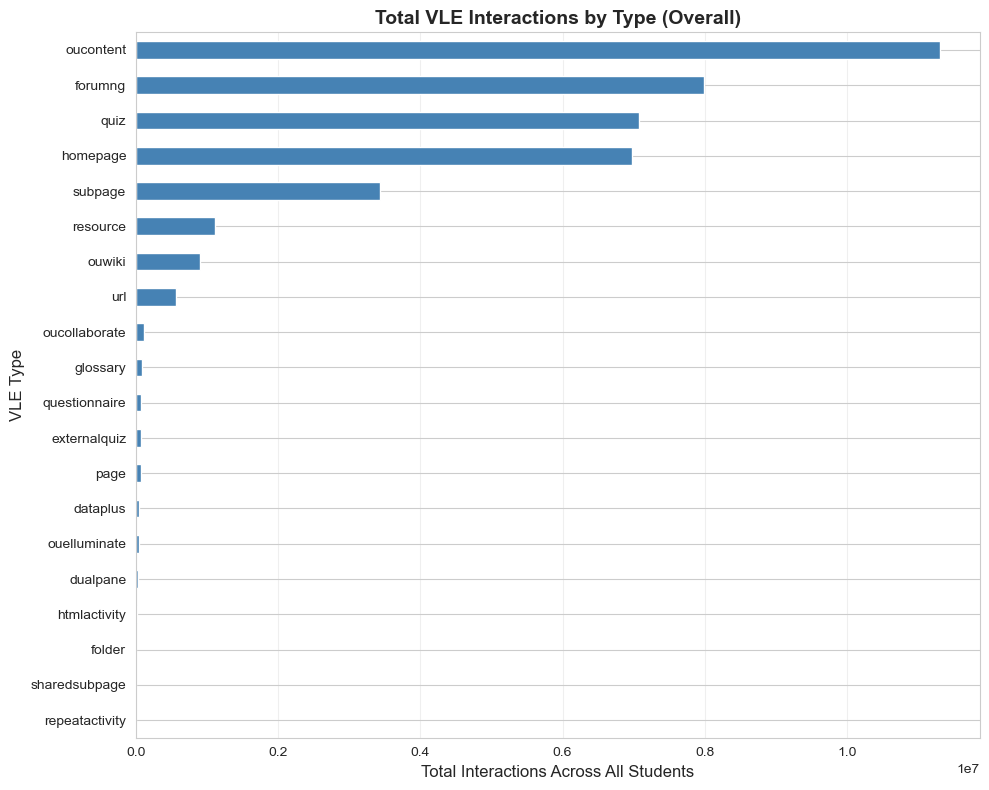

In [6]:
# Plot total interactions by VLE type
vle_totals = different_vle_interactions_overall[vle_columns].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
vle_totals.plot(kind='barh', color='steelblue')
plt.xlabel('Total Interactions Across All Students', fontsize=12)
plt.ylabel('VLE Type', fontsize=12)
plt.title('Total VLE Interactions by Type (Overall)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Checking final_result column type...
Data type: object
Unique values: ['Distinction', 'Fail', 'Pass', 'Withdrawn']

Converting final_result from strings to numeric codes...
Mapping applied: {'Withdraw': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
BASIC EDA: VLE INTERACTIONS vs FINAL RESULT

1. DESCRIPTIVE STATISTICS BY FINAL RESULT

Mean VLE interactions by final_result:
              forumng  homepage  oucontent  subpage    url  resource  \
final_result                                                           
Distinction    672.54    501.39     762.77   209.43  36.35     64.89   
Fail           136.16    140.57     215.81    81.36  12.59     28.03   
Pass           401.32    352.53     607.18   173.00  28.37     55.25   
Withdrawn      152.60    145.37     206.15    76.05  13.17     25.85   

              glossary  dataplus  oucollaborate    quiz  ouelluminate  \
final_result                                                            
Distinction       7.05      5.31           6.93 

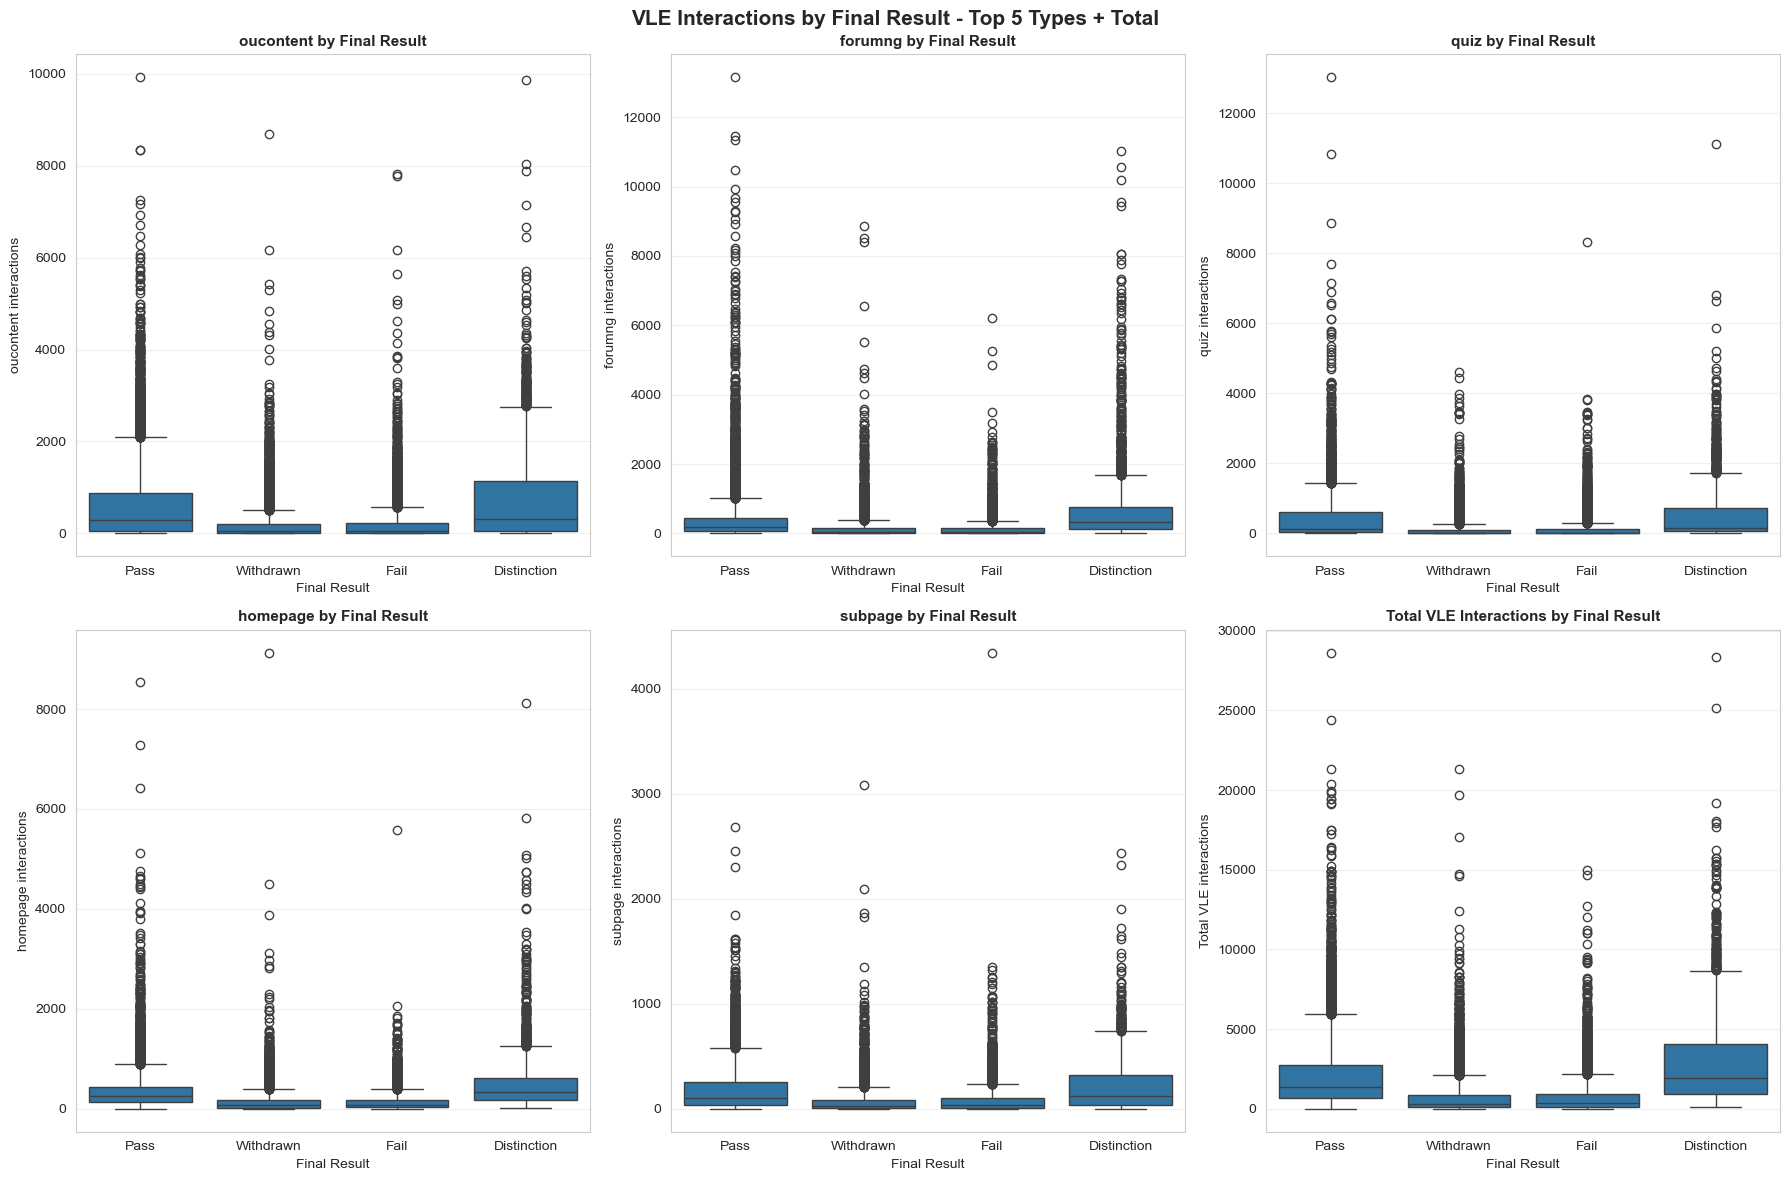

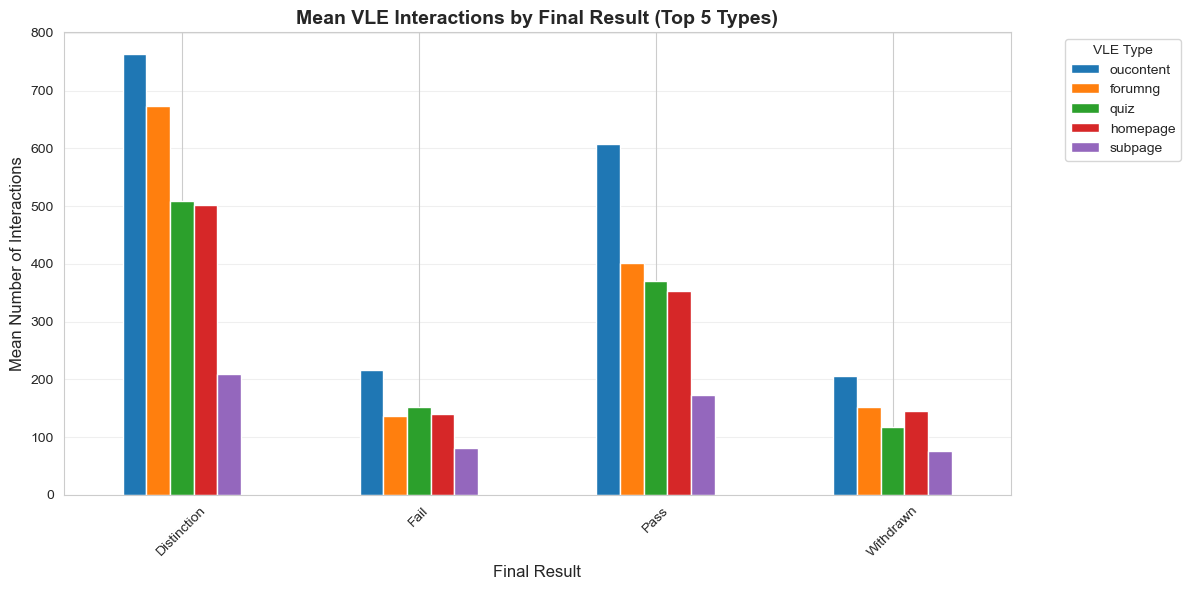

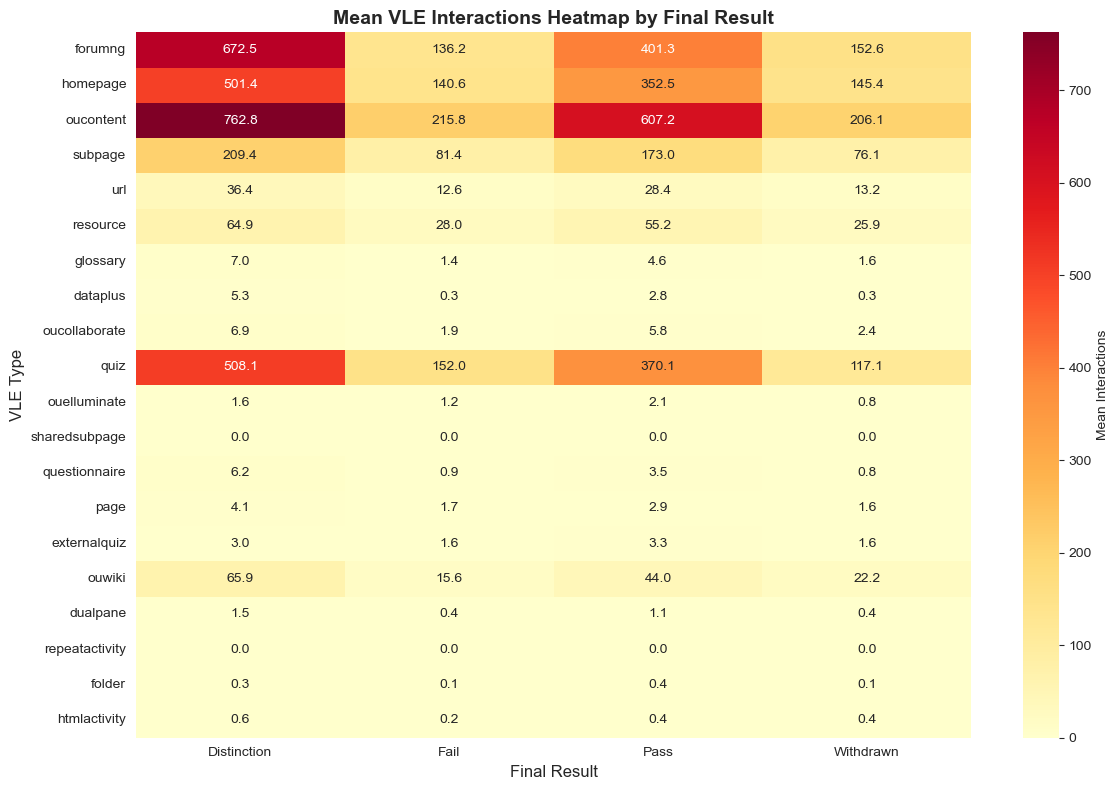

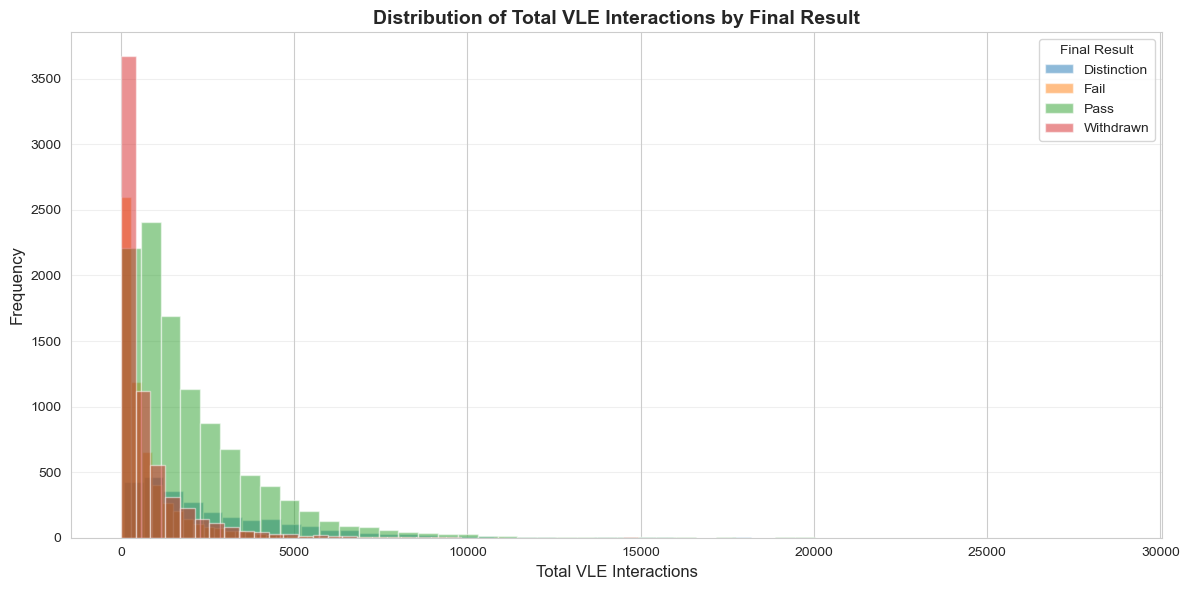


5. VLE TYPE RANKING BY TOTAL USAGE

Total interactions by VLE type (ranked):
 1. oucontent           :   11,307,819
 2. forumng             :    7,989,106
 3. quiz                :    7,074,810
 4. homepage            :    6,979,423
 5. subpage             :    3,432,601
 6. resource            :    1,113,347
 7. ouwiki              :      895,267
 8. url                 :      568,213
 9. oucollaborate       :      109,069
10. glossary            :       88,050
11. questionnaire       :       65,040
12. externalquiz        :       64,345
13. page                :       63,897
14. dataplus            :       48,310
15. ouelluminate        :       39,149
16. dualpane            :       20,878
17. htmlactivity        :        9,251
18. folder              :        5,849
19. sharedsubpage       :          171
20. repeatactivity      :            9


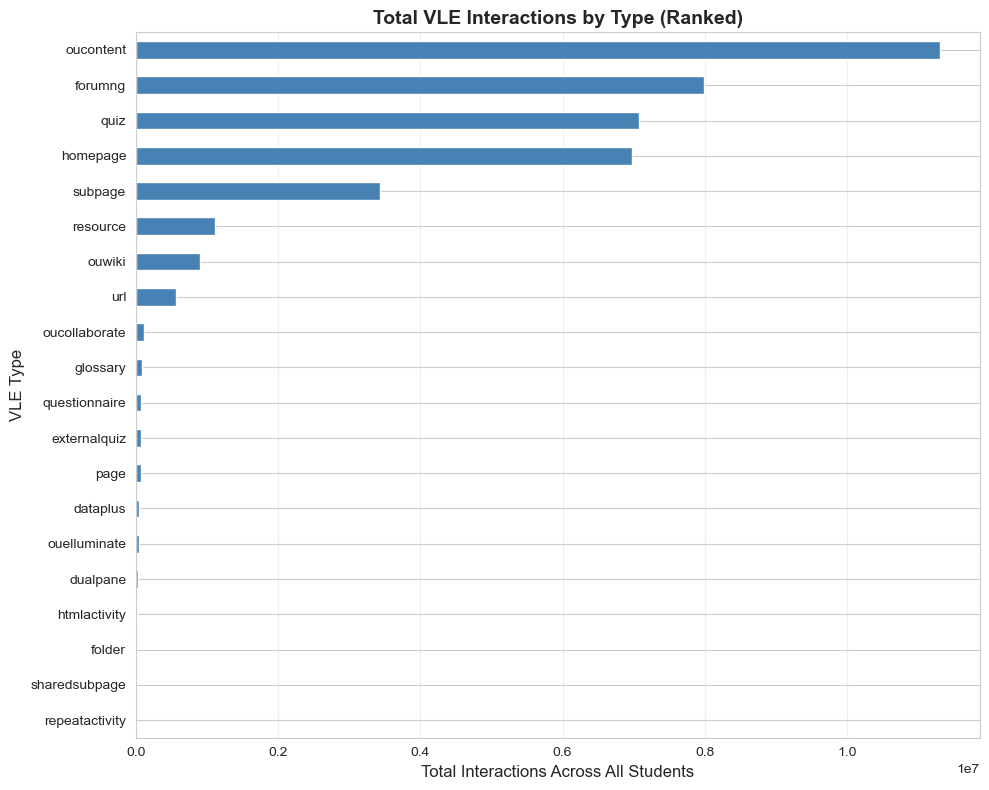


6. CORRELATION BETWEEN VLE TYPES AND FINAL RESULT

Correlation with final_result (ranked):
total_vle_interactions   :  0.3380
homepage                 :  0.3135
oucontent                :  0.2523
forumng                  :  0.2399
subpage                  :  0.2363
quiz                     :  0.2139
questionnaire            :  0.2013
url                      :  0.1949
dataplus                 :  0.1862
ouwiki                   :  0.1670
resource                 :  0.1500
oucollaborate            :  0.1453
page                     :  0.1160
dualpane                 :  0.1071
htmlactivity             :  0.0769
folder                   :  0.0704
externalquiz             :  0.0608
glossary                 :  0.0446
ouelluminate             :  0.0269
sharedsubpage            :  0.0094
repeatactivity           : -0.0066


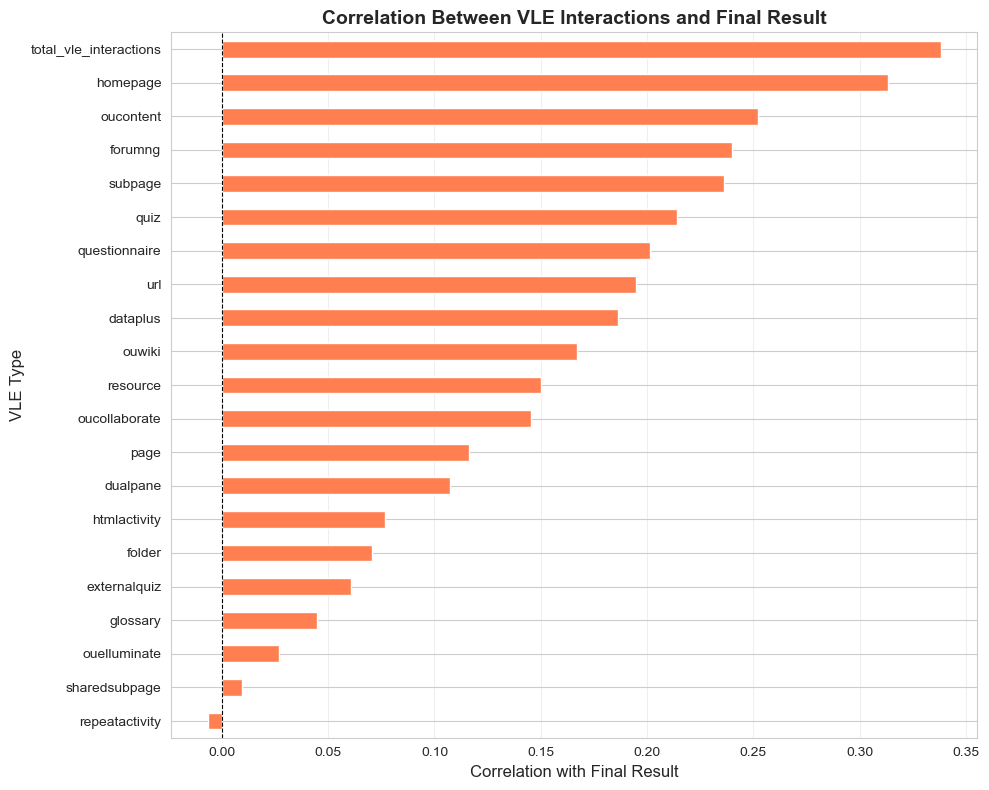

In [8]:
from scipy import stats

vle_columns = [
    "forumng", "homepage", "oucontent", "subpage", "url", "resource", 
    "glossary", "dataplus", "oucollaborate", "quiz", "ouelluminate", 
    "sharedsubpage", "questionnaire", "page", "externalquiz", "ouwiki", 
    "dualpane", "repeatactivity", "folder", "htmlactivity"
]

# CHECK AND CONVERT FINAL_RESULT TO NUMERIC IF NEEDED
print("Checking final_result column type...")
print(f"Data type: {different_vle_interactions_overall['final_result'].dtype}")
print(f"Unique values: {sorted(different_vle_interactions_overall['final_result'].unique())}")

# If final_result is string/object, convert to numeric
if different_vle_interactions_overall['final_result'].dtype == 'object':
    print("\nConverting final_result from strings to numeric codes...")
    
    # Create mapping
    result_mapping = {
        'Withdraw': 0,
        'Fail': 1,
        'Pass': 2,
        'Distinction': 3
    }
    
    # Create numeric version
    different_vle_interactions_overall['final_result_numeric'] = different_vle_interactions_overall['final_result'].map(result_mapping)
    
    # Use numeric version for analysis
    result_col = 'final_result_numeric'
    print(f"Mapping applied: {result_mapping}")
else:
    result_col = 'final_result'

print("="*80)
print("BASIC EDA: VLE INTERACTIONS vs FINAL RESULT")
print("="*80)

# 1. DESCRIPTIVE STATISTICS BY FINAL RESULT
print("\n" + "="*80)
print("1. DESCRIPTIVE STATISTICS BY FINAL RESULT")
print("="*80)

print("\nMean VLE interactions by final_result:")
mean_by_result = different_vle_interactions_overall.groupby('final_result')[vle_columns].mean()
print(mean_by_result.round(2))

print("\nMedian VLE interactions by final_result:")
median_by_result = different_vle_interactions_overall.groupby('final_result')[vle_columns].median()
print(median_by_result.round(2))

# 2. TOTAL VLE USAGE (sum of all VLE interactions)
print("\n" + "="*80)
print("2. TOTAL VLE USAGE ANALYSIS")
print("="*80)

# Create total VLE interactions column
different_vle_interactions_overall['total_vle_interactions'] = different_vle_interactions_overall[vle_columns].sum(axis=1)

print("\nTotal VLE interactions by final_result:")
print(different_vle_interactions_overall.groupby('final_result')['total_vle_interactions'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(2))

# 3. STATISTICAL TESTS - Kruskal-Wallis for top 5 VLE types
print("\n" + "="*80)
print("3. STATISTICAL TESTS (Kruskal-Wallis) - Top 5 Most Used VLE Types")
print("="*80)

# Find top 5 most used VLE types
top_5_vle = different_vle_interactions_overall[vle_columns].sum().nlargest(5).index.tolist()

for vle in top_5_vle:
    groups = [different_vle_interactions_overall[different_vle_interactions_overall['final_result'] == i][vle].values 
              for i in sorted(different_vle_interactions_overall['final_result'].unique())]
    h_stat, p_value = stats.kruskal(*groups)
    
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"\n{vle}:")
    print(f"  H-statistic: {h_stat:.4f}, p-value: {p_value:.6f} {significance}")

# Test for total VLE interactions
groups_total = [different_vle_interactions_overall[different_vle_interactions_overall['final_result'] == i]['total_vle_interactions'].values 
                for i in sorted(different_vle_interactions_overall['final_result'].unique())]
h_total, p_total = stats.kruskal(*groups_total)
print(f"\ntotal_vle_interactions:")
print(f"  H-statistic: {h_total:.4f}, p-value: {p_total:.6f} {'***' if p_total < 0.001 else '**' if p_total < 0.01 else '*' if p_total < 0.05 else 'ns'}")

print("\n* p < 0.05, ** p < 0.01, *** p < 0.001, ns = not significant")

# 4. VISUALIZATIONS

# 4a. Box plots for top 5 VLE types
print("\n" + "="*80)
print("4. GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Top 5 VLE types
for idx, vle in enumerate(top_5_vle):
    sns.boxplot(x='final_result', y=vle, data=different_vle_interactions_overall, ax=axes[idx])
    axes[idx].set_xlabel('Final Result', fontsize=10)
    axes[idx].set_ylabel(f'{vle} interactions', fontsize=10)
    axes[idx].set_title(f'{vle} by Final Result', fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

# Total VLE interactions
sns.boxplot(x='final_result', y='total_vle_interactions', data=different_vle_interactions_overall, ax=axes[5])
axes[5].set_xlabel('Final Result', fontsize=10)
axes[5].set_ylabel('Total VLE interactions', fontsize=10)
axes[5].set_title('Total VLE Interactions by Final Result', fontsize=11, fontweight='bold')
axes[5].grid(axis='y', alpha=0.3)

plt.suptitle('VLE Interactions by Final Result - Top 5 Types + Total', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 4b. Bar plot - Mean interactions by final result
fig, ax = plt.subplots(figsize=(12, 6))
mean_by_result_top5 = different_vle_interactions_overall.groupby('final_result')[top_5_vle].mean()
mean_by_result_top5.plot(kind='bar', ax=ax)
ax.set_xlabel('Final Result', fontsize=12)
ax.set_ylabel('Mean Number of Interactions', fontsize=12)
ax.set_title('Mean VLE Interactions by Final Result (Top 5 Types)', fontsize=14, fontweight='bold')
ax.legend(title='VLE Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4c. Heatmap - Mean interactions by final result (all VLE types)
fig, ax = plt.subplots(figsize=(12, 8))
mean_by_result_all = different_vle_interactions_overall.groupby('final_result')[vle_columns].mean()
sns.heatmap(mean_by_result_all.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Interactions'}, ax=ax)
ax.set_xlabel('Final Result', fontsize=12)
ax.set_ylabel('VLE Type', fontsize=12)
ax.set_title('Mean VLE Interactions Heatmap by Final Result', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4d. Distribution of total VLE interactions
fig, ax = plt.subplots(figsize=(12, 6))
for result in sorted(different_vle_interactions_overall['final_result'].unique()):
    subset = different_vle_interactions_overall[different_vle_interactions_overall['final_result'] == result]['total_vle_interactions']
    ax.hist(subset, bins=50, alpha=0.5, label=f'{result}')
ax.set_xlabel('Total VLE Interactions', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Total VLE Interactions by Final Result', fontsize=14, fontweight='bold')
ax.legend(title='Final Result')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. RANKING OF VLE TYPES BY USAGE
print("\n" + "="*80)
print("5. VLE TYPE RANKING BY TOTAL USAGE")
print("="*80)

vle_totals = different_vle_interactions_overall[vle_columns].sum().sort_values(ascending=False)
print("\nTotal interactions by VLE type (ranked):")
for idx, (vle, total) in enumerate(vle_totals.items(), 1):
    print(f"{idx:2d}. {vle:20s}: {total:>12,.0f}")

# Visualization of all VLE types ranked
fig, ax = plt.subplots(figsize=(10, 8))
vle_totals.sort_values(ascending=True).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Total Interactions Across All Students', fontsize=12)
ax.set_ylabel('VLE Type', fontsize=12)
ax.set_title('Total VLE Interactions by Type (Ranked)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 6. CORRELATION ANALYSIS (using numeric version of final_result)
print("\n" + "="*80)
print("6. CORRELATION BETWEEN VLE TYPES AND FINAL RESULT")
print("="*80)

# Calculate correlation with final_result (numeric version)
correlations = different_vle_interactions_overall[vle_columns + ['total_vle_interactions']].corrwith(
    different_vle_interactions_overall[result_col]
).sort_values(ascending=False)

print("\nCorrelation with final_result (ranked):")
for vle, corr in correlations.items():
    print(f"{vle:25s}: {corr:>7.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
correlations.sort_values(ascending=True).plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Correlation with Final Result', fontsize=12)
ax.set_ylabel('VLE Type', fontsize=12)
ax.set_title('Correlation Between VLE Interactions and Final Result', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Create a "week" column relative to each code_presentation's starting date. 
# Dates 0.0 - 6.0 are week 1, 7.0 - 13.0 are week 2, etc. 
# The weeks *before* date 0.0 are assigned to negative values. 

df['week'] = df.groupby('code_presentation')['date'].transform(
    lambda x: ((x // 7) + 1).where(x >= 0, x // 7)
)
df.head(10)

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,week
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-2.0
5,6516,AAA,2014J,-6.0,12,4,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0
6,6516,AAA,2014J,-5.0,0,7,5,1,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0
7,6516,AAA,2014J,-2.0,2,8,23,5,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0
8,6516,AAA,2014J,-1.0,3,7,15,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0
9,6516,AAA,2014J,0.0,48,11,1,5,6,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,1.0


In [11]:
# Now creating VLE table for week 1 for more EDA

vle_columns = [
    "forumng", "homepage", "oucontent", "subpage", "url", "resource", 
    "glossary", "dataplus", "oucollaborate", "quiz", "ouelluminate", 
    "sharedsubpage", "questionnaire", "page", "externalquiz", "ouwiki", 
    "dualpane", "repeatactivity", "folder", "htmlactivity"
]

# Filter data to only week 1
df_week1 = df[df['week'] == 1].copy()

print("="*70)
print("FILTERING DATA FOR WEEK 1")
print("="*70)
print(f"Original dataframe rows: {len(df)}")
print(f"Week 1 rows: {len(df_week1)}")
print(f"Unique students in week 1: {df_week1['id_student'].nunique()}")

# Create aggregation dictionary
agg_dict = {
    'code_module': 'first',
    'code_presentation': 'first',
    'final_result': 'first'
}

# Add all VLE columns to aggregate (sum them)
for col in vle_columns:
    agg_dict[col] = 'sum'

# Aggregate to student level for week 1
different_vle_interactions_w1 = df_week1.groupby('id_student').agg(agg_dict).reset_index()


FILTERING DATA FOR WEEK 1
Original dataframe rows: 1875496
Week 1 rows: 75546
Unique students in week 1: 21464


Checking final_result column type...
Data type: object
Unique values: ['Distinction', 'Fail', 'Pass', 'Withdrawn']

Converting final_result from strings to numeric codes...
Mapping applied: {'Withdraw': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
BASIC EDA: WEEK 1 VLE INTERACTIONS vs FINAL RESULT

1. DESCRIPTIVE STATISTICS BY FINAL RESULT (Week 1)

Mean Week 1 VLE interactions by final_result:
              forumng  homepage  oucontent  subpage   url  resource  glossary  \
final_result                                                                    
Distinction     50.55     25.58      19.14    12.79  2.36      4.62      0.41   
Fail            21.77     14.11      12.17     8.57  1.67      3.31      0.21   
Pass            34.35     19.75      17.67    10.44  1.91      3.54      0.32   
Withdrawn       27.03     17.28      15.25    10.00  1.79      3.42      0.22   

              dataplus  oucollaborate   quiz  ouelluminate  sharedsubpage  \
final_result                            

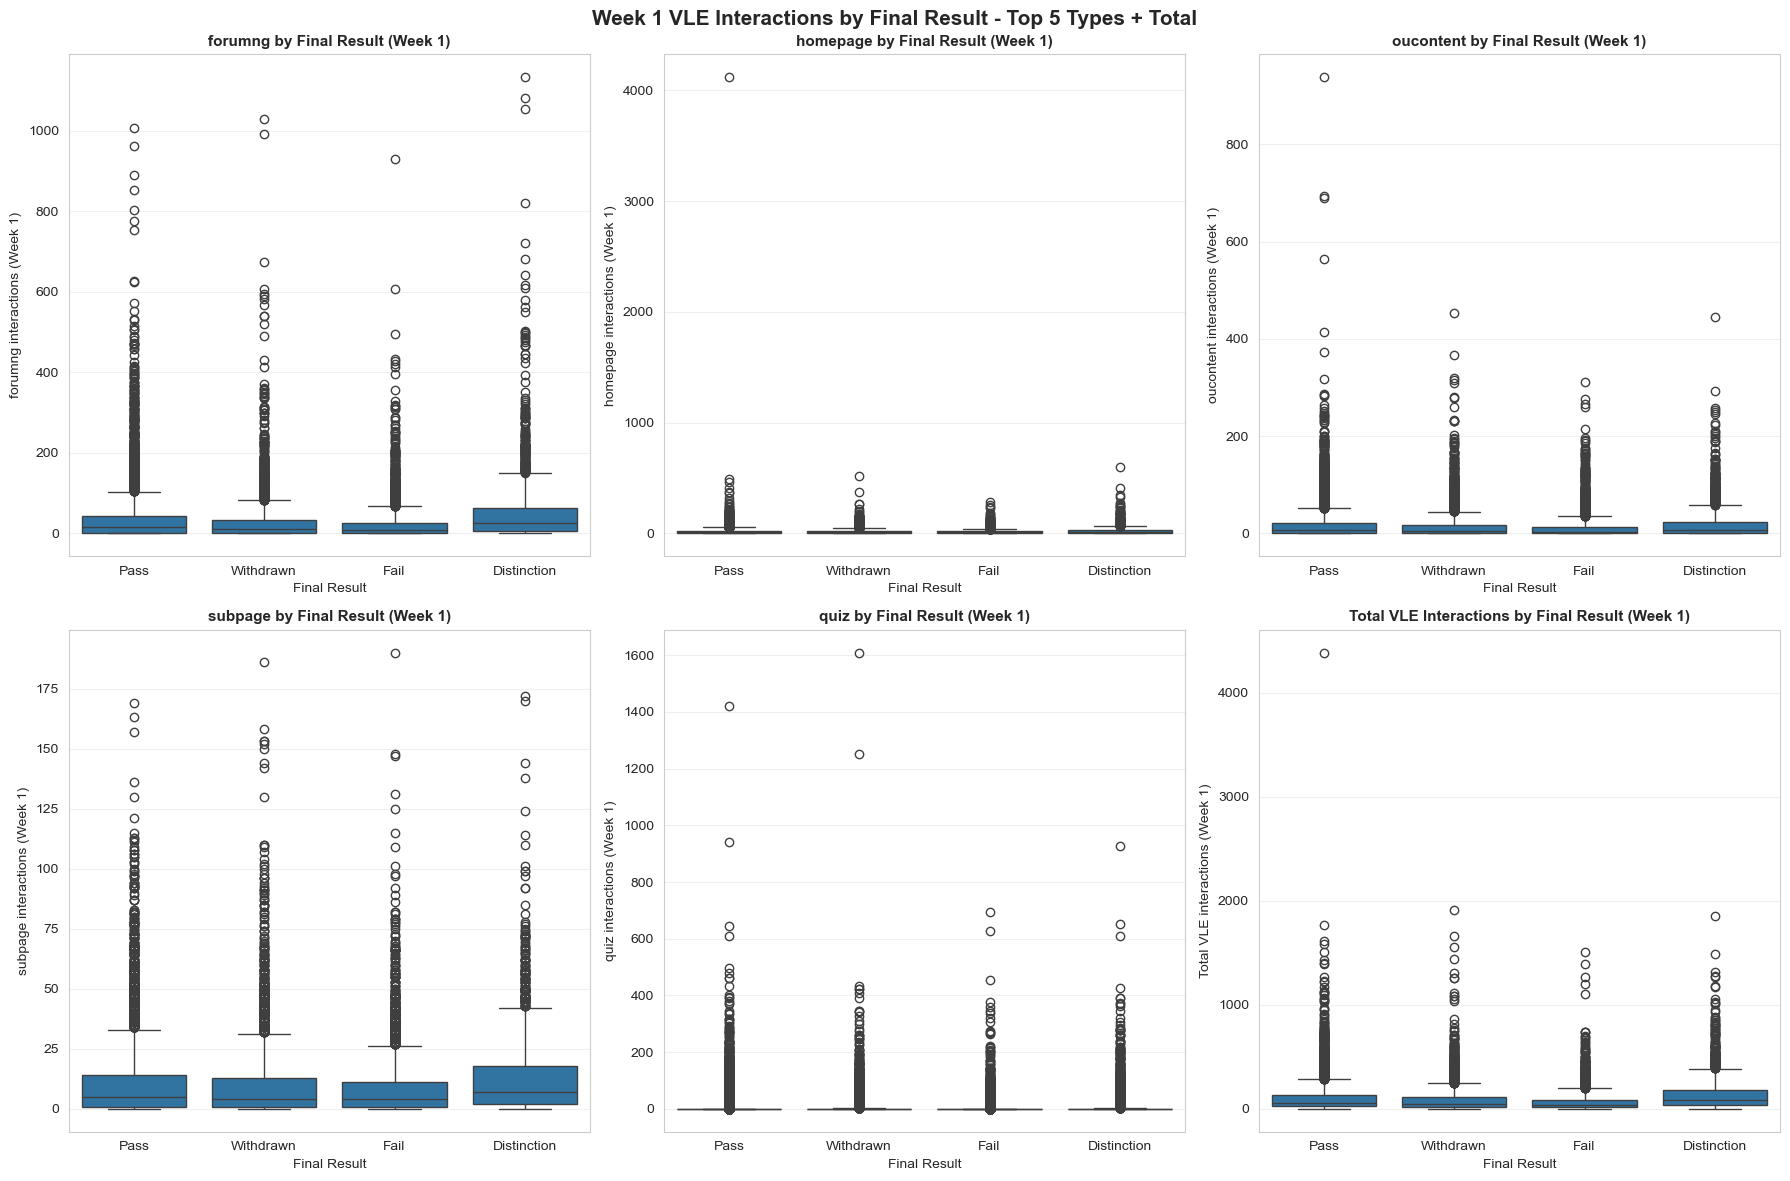

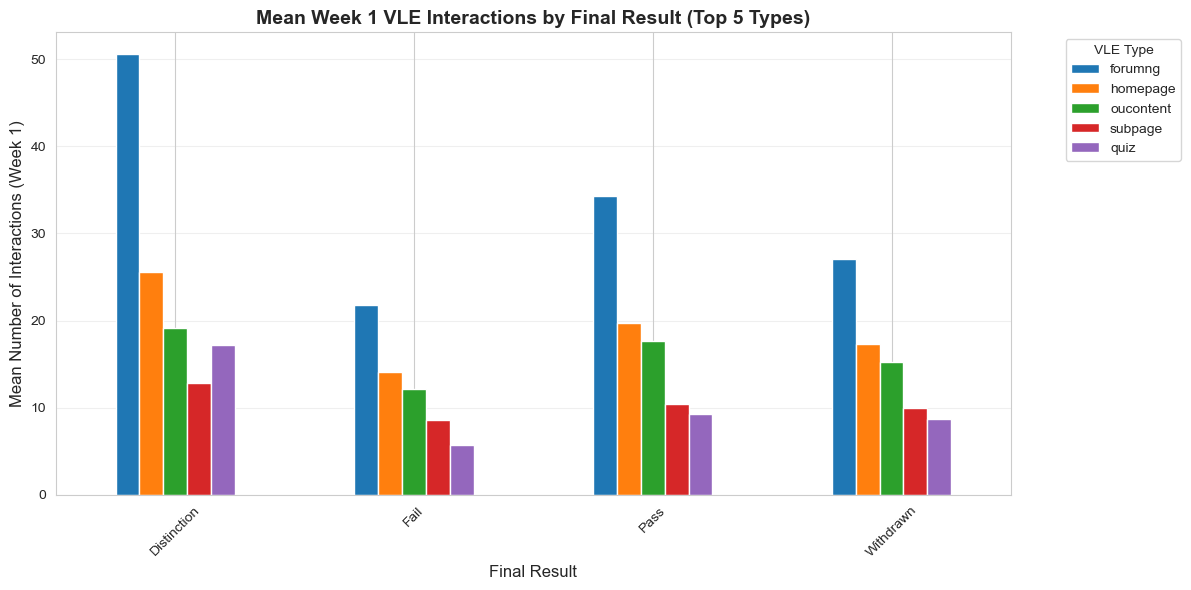

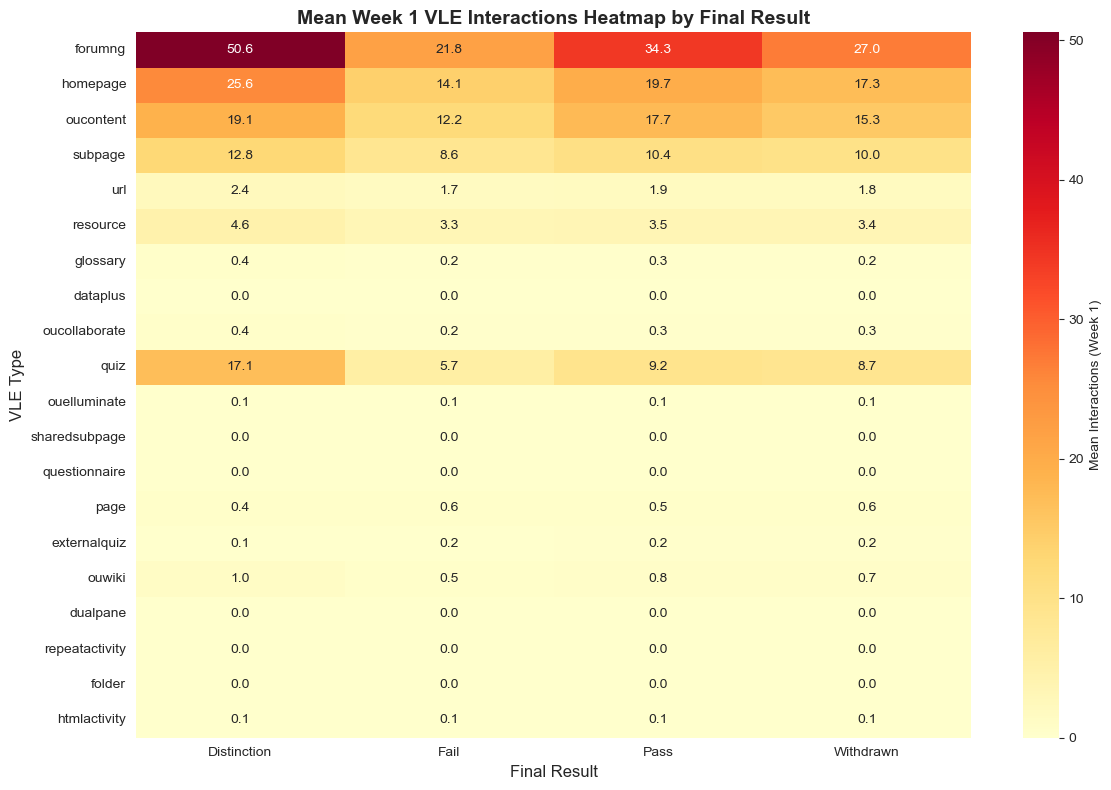

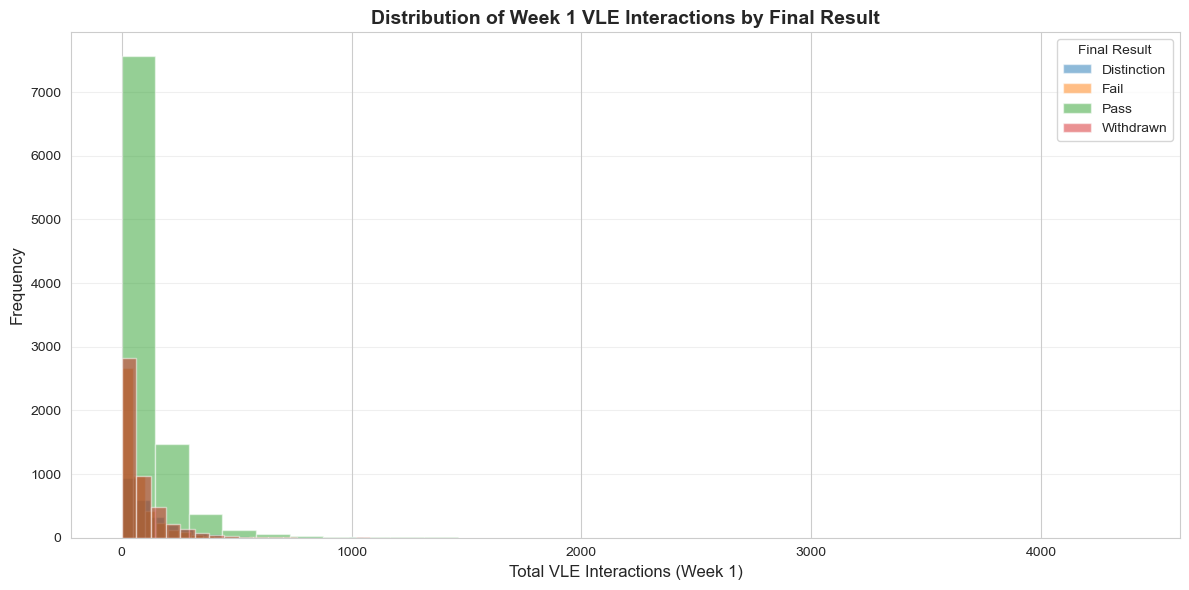


5. VLE TYPE RANKING BY WEEK 1 USAGE

Total interactions by VLE type (ranked, Week 1):
 1. forumng             :      683,410
 2. homepage            :      400,178
 3. oucontent           :      345,824
 4. subpage             :      219,039
 5. quiz                :      198,810
 6. resource            :       76,962
 7. url                 :       40,323
 8. ouwiki              :       15,600
 9. page                :       11,287
10. oucollaborate       :        6,800
11. glossary            :        6,106
12. externalquiz        :        4,167
13. ouelluminate        :        2,718
14. htmlactivity        :        2,705
15. dualpane            :          433
16. questionnaire       :          207
17. dataplus            :           57
18. sharedsubpage       :           21
19. repeatactivity      :            0
20. folder              :            0


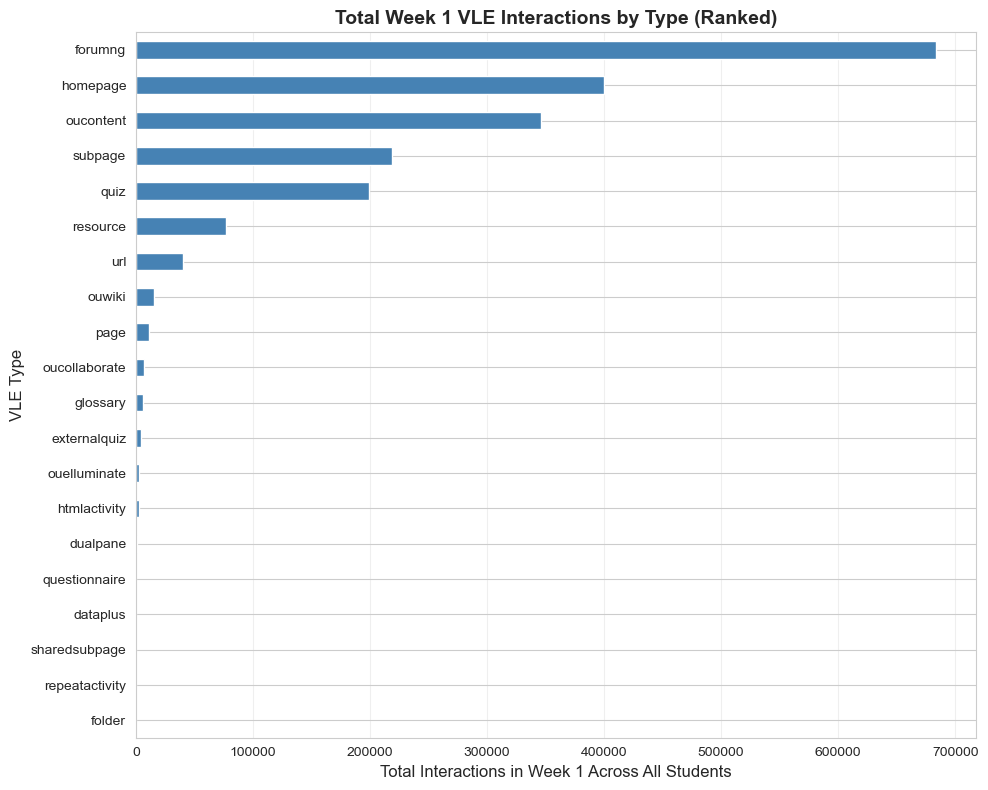


6. CORRELATION BETWEEN WEEK 1 VLE TYPES AND FINAL RESULT

Correlation with final_result (ranked, Week 1 data):
total_vle_interactions_w1     :  0.1602
forumng                       :  0.1495
homepage                      :  0.0911
subpage                       :  0.0903
quiz                          :  0.0874
oucontent                     :  0.0803
url                           :  0.0520
resource                      :  0.0477
ouwiki                        :  0.0473
oucollaborate                 :  0.0459
htmlactivity                  :  0.0275
glossary                      :  0.0232
questionnaire                 :  0.0174
dataplus                      :  0.0087
dualpane                      :  0.0073
externalquiz                  : -0.0007
ouelluminate                  : -0.0011
sharedsubpage                 : -0.0050
page                          : -0.0266
repeatactivity                :     nan
folder                        :     nan


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


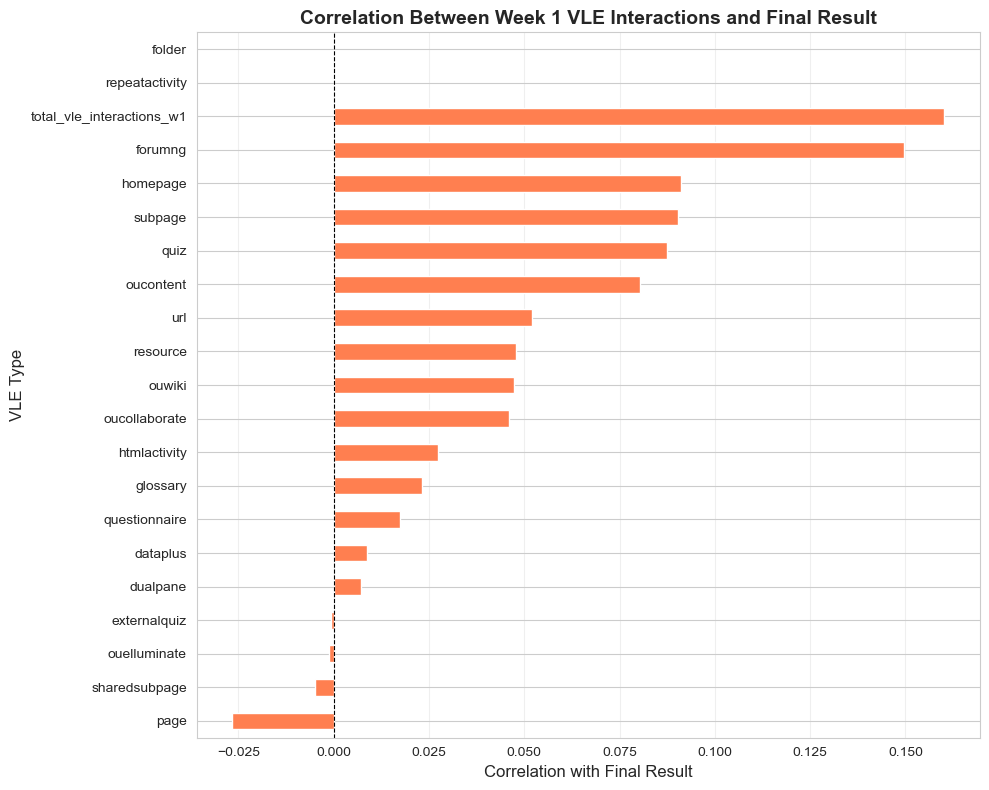


7. ENGAGEMENT PATTERNS IN WEEK 1

Engagement categories in Week 1:
engagement_w1
None (0)             21
Low (1-10)         3131
Medium (11-50)     7106
High (>50)        11206
Name: count, dtype: int64

Engagement by final_result:
engagement_w1  None (0)  Low (1-10)  Medium (11-50)  High (>50)
final_result                                                   
Distinction        0.04        7.46           26.30       66.20
Fail               0.04       20.60           37.13       42.23
Pass               0.15       12.20           32.30       55.36
Withdrawn          0.08       17.19           34.30       48.42


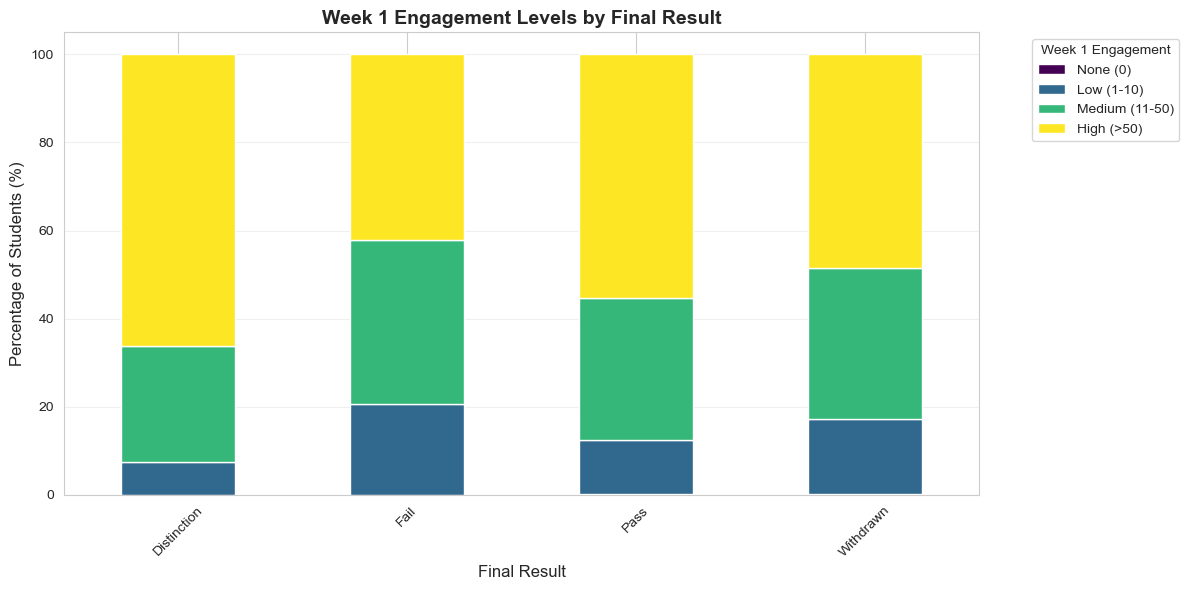

In [12]:
vle_columns = [
    "forumng", "homepage", "oucontent", "subpage", "url", "resource", 
    "glossary", "dataplus", "oucollaborate", "quiz", "ouelluminate", 
    "sharedsubpage", "questionnaire", "page", "externalquiz", "ouwiki", 
    "dualpane", "repeatactivity", "folder", "htmlactivity"
]

# CHECK AND CONVERT FINAL_RESULT TO NUMERIC IF NEEDED
print("Checking final_result column type...")
print(f"Data type: {different_vle_interactions_w1['final_result'].dtype}")
print(f"Unique values: {sorted(different_vle_interactions_w1['final_result'].unique())}")

# If final_result is string/object, convert to numeric
if different_vle_interactions_w1['final_result'].dtype == 'object':
    print("\nConverting final_result from strings to numeric codes...")
    
    # Create mapping
    result_mapping = {
        'Withdraw': 0,
        'Fail': 1,
        'Pass': 2,
        'Distinction': 3
    }
    
    # Create numeric version
    different_vle_interactions_w1['final_result_numeric'] = different_vle_interactions_w1['final_result'].map(result_mapping)
    
    # Use numeric version for correlation analysis
    result_col = 'final_result_numeric'
    print(f"Mapping applied: {result_mapping}")
else:
    result_col = 'final_result'

print("="*80)
print("BASIC EDA: WEEK 1 VLE INTERACTIONS vs FINAL RESULT")
print("="*80)

# 1. DESCRIPTIVE STATISTICS BY FINAL RESULT
print("\n" + "="*80)
print("1. DESCRIPTIVE STATISTICS BY FINAL RESULT (Week 1)")
print("="*80)

print("\nMean Week 1 VLE interactions by final_result:")
mean_by_result = different_vle_interactions_w1.groupby('final_result')[vle_columns].mean()
print(mean_by_result.round(2))

print("\nMedian Week 1 VLE interactions by final_result:")
median_by_result = different_vle_interactions_w1.groupby('final_result')[vle_columns].median()
print(median_by_result.round(2))

# 2. TOTAL VLE USAGE IN WEEK 1 (sum of all VLE interactions)
print("\n" + "="*80)
print("2. TOTAL VLE USAGE ANALYSIS (Week 1)")
print("="*80)

# Create total VLE interactions column if not already exists
if 'total_vle_interactions_w1' not in different_vle_interactions_w1.columns:
    different_vle_interactions_w1['total_vle_interactions_w1'] = different_vle_interactions_w1[vle_columns].sum(axis=1)

print("\nTotal Week 1 VLE interactions by final_result:")
print(different_vle_interactions_w1.groupby('final_result')['total_vle_interactions_w1'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).round(2))

# Check how many students had zero activity in week 1
zero_activity = (different_vle_interactions_w1['total_vle_interactions_w1'] == 0).sum()
print(f"\nStudents with ZERO interactions in Week 1: {zero_activity} ({zero_activity/len(different_vle_interactions_w1)*100:.1f}%)")

print("\nZero activity by final_result:")
for result in sorted(different_vle_interactions_w1['final_result'].unique()):
    subset = different_vle_interactions_w1[different_vle_interactions_w1['final_result'] == result]
    zero_count = (subset['total_vle_interactions_w1'] == 0).sum()
    print(f"  {result}: {zero_count} ({zero_count/len(subset)*100:.1f}%)")

# 3. STATISTICAL TESTS - Kruskal-Wallis for top 5 VLE types
print("\n" + "="*80)
print("3. STATISTICAL TESTS (Kruskal-Wallis) - Top 5 Most Used VLE Types in Week 1")
print("="*80)

# Find top 5 most used VLE types in week 1
top_5_vle = different_vle_interactions_w1[vle_columns].sum().nlargest(5).index.tolist()

for vle in top_5_vle:
    groups = [different_vle_interactions_w1[different_vle_interactions_w1['final_result'] == i][vle].values 
              for i in sorted(different_vle_interactions_w1['final_result'].unique())]
    h_stat, p_value = stats.kruskal(*groups)
    
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"\n{vle}:")
    print(f"  H-statistic: {h_stat:.4f}, p-value: {p_value:.6f} {significance}")

# Test for total VLE interactions
groups_total = [different_vle_interactions_w1[different_vle_interactions_w1['final_result'] == i]['total_vle_interactions_w1'].values 
                for i in sorted(different_vle_interactions_w1['final_result'].unique())]
h_total, p_total = stats.kruskal(*groups_total)
print(f"\ntotal_vle_interactions_w1:")
print(f"  H-statistic: {h_total:.4f}, p-value: {p_total:.6f} {'***' if p_total < 0.001 else '**' if p_total < 0.01 else '*' if p_total < 0.05 else 'ns'}")

print("\n* p < 0.05, ** p < 0.01, *** p < 0.001, ns = not significant")

# 4. VISUALIZATIONS

# 4a. Box plots for top 5 VLE types
print("\n" + "="*80)
print("4. GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Top 5 VLE types
for idx, vle in enumerate(top_5_vle):
    sns.boxplot(x='final_result', y=vle, data=different_vle_interactions_w1, ax=axes[idx])
    axes[idx].set_xlabel('Final Result', fontsize=10)
    axes[idx].set_ylabel(f'{vle} interactions (Week 1)', fontsize=10)
    axes[idx].set_title(f'{vle} by Final Result (Week 1)', fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

# Total VLE interactions
sns.boxplot(x='final_result', y='total_vle_interactions_w1', data=different_vle_interactions_w1, ax=axes[5])
axes[5].set_xlabel('Final Result', fontsize=10)
axes[5].set_ylabel('Total VLE interactions (Week 1)', fontsize=10)
axes[5].set_title('Total VLE Interactions by Final Result (Week 1)', fontsize=11, fontweight='bold')
axes[5].grid(axis='y', alpha=0.3)

plt.suptitle('Week 1 VLE Interactions by Final Result - Top 5 Types + Total', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 4b. Bar plot - Mean interactions by final result
fig, ax = plt.subplots(figsize=(12, 6))
mean_by_result_top5 = different_vle_interactions_w1.groupby('final_result')[top_5_vle].mean()
mean_by_result_top5.plot(kind='bar', ax=ax)
ax.set_xlabel('Final Result', fontsize=12)
ax.set_ylabel('Mean Number of Interactions (Week 1)', fontsize=12)
ax.set_title('Mean Week 1 VLE Interactions by Final Result (Top 5 Types)', fontsize=14, fontweight='bold')
ax.legend(title='VLE Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4c. Heatmap - Mean interactions by final result (all VLE types)
fig, ax = plt.subplots(figsize=(12, 8))
mean_by_result_all = different_vle_interactions_w1.groupby('final_result')[vle_columns].mean()
sns.heatmap(mean_by_result_all.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Interactions (Week 1)'}, ax=ax)
ax.set_xlabel('Final Result', fontsize=12)
ax.set_ylabel('VLE Type', fontsize=12)
ax.set_title('Mean Week 1 VLE Interactions Heatmap by Final Result', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4d. Distribution of total VLE interactions in week 1
fig, ax = plt.subplots(figsize=(12, 6))
for result in sorted(different_vle_interactions_w1['final_result'].unique()):
    subset = different_vle_interactions_w1[different_vle_interactions_w1['final_result'] == result]['total_vle_interactions_w1']
    ax.hist(subset, bins=30, alpha=0.5, label=f'{result}')
ax.set_xlabel('Total VLE Interactions (Week 1)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Week 1 VLE Interactions by Final Result', fontsize=14, fontweight='bold')
ax.legend(title='Final Result')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. RANKING OF VLE TYPES BY USAGE IN WEEK 1
print("\n" + "="*80)
print("5. VLE TYPE RANKING BY WEEK 1 USAGE")
print("="*80)

vle_totals = different_vle_interactions_w1[vle_columns].sum().sort_values(ascending=False)
print("\nTotal interactions by VLE type (ranked, Week 1):")
for idx, (vle, total) in enumerate(vle_totals.items(), 1):
    print(f"{idx:2d}. {vle:20s}: {total:>12,.0f}")

# Visualization of all VLE types ranked
fig, ax = plt.subplots(figsize=(10, 8))
vle_totals.sort_values(ascending=True).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Total Interactions in Week 1 Across All Students', fontsize=12)
ax.set_ylabel('VLE Type', fontsize=12)
ax.set_title('Total Week 1 VLE Interactions by Type (Ranked)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 6. CORRELATION ANALYSIS
print("\n" + "="*80)
print("6. CORRELATION BETWEEN WEEK 1 VLE TYPES AND FINAL RESULT")
print("="*80)

# Calculate correlation with final_result (numeric version)
correlations = different_vle_interactions_w1[vle_columns + ['total_vle_interactions_w1']].corrwith(
    different_vle_interactions_w1[result_col]
).sort_values(ascending=False)

print("\nCorrelation with final_result (ranked, Week 1 data):")
for vle, corr in correlations.items():
    print(f"{vle:30s}: {corr:>7.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
correlations.sort_values(ascending=True).plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Correlation with Final Result', fontsize=12)
ax.set_ylabel('VLE Type', fontsize=12)
ax.set_title('Correlation Between Week 1 VLE Interactions and Final Result', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 7. ENGAGEMENT PATTERNS - Active vs Inactive Students in Week 1
print("\n" + "="*80)
print("7. ENGAGEMENT PATTERNS IN WEEK 1")
print("="*80)

# Create engagement categories
different_vle_interactions_w1['engagement_w1'] = pd.cut(
    different_vle_interactions_w1['total_vle_interactions_w1'],
    bins=[-1, 0, 10, 50, float('inf')],
    labels=['None (0)', 'Low (1-10)', 'Medium (11-50)', 'High (>50)']
)

print("\nEngagement categories in Week 1:")
print(different_vle_interactions_w1['engagement_w1'].value_counts().sort_index())

print("\nEngagement by final_result:")
engagement_crosstab = pd.crosstab(
    different_vle_interactions_w1['final_result'],
    different_vle_interactions_w1['engagement_w1'],
    normalize='index'
) * 100
print(engagement_crosstab.round(2))

# Visualize engagement patterns
fig, ax = plt.subplots(figsize=(12, 6))
engagement_crosstab.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_xlabel('Final Result', fontsize=12)
ax.set_ylabel('Percentage of Students (%)', fontsize=12)
ax.set_title('Week 1 Engagement Levels by Final Result', fontsize=14, fontweight='bold')
ax.legend(title='Week 1 Engagement', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()